### Load Function code from File:

In [1]:
# %load ../oanda_downloader/featureEngineering.py
import calendar
from datetime import datetime, timedelta
import time
from zoneinfo import ZoneInfo
import pandas as pd
import ta
import random

random.seed(10765)
pd.options.mode.copy_on_write = True
# pd.options.mode.copy_on_write = False
df = None
baseDataPath = './data/'

def load_df_from_parquet(parquetFile):
    #Load optimised dataframe from parquet file
    start = time.time()
    dfFile = parquetFile
    df = pd.read_parquet(path=dfFile)
    end = time.time()
    print(f"Loaded Parquet Data:{parquetFile}, took:{end - start}")
    return df

def week_of_month(tgtdate):

    days_this_month = calendar.mdays[tgtdate.month]
    for i in range(1, days_this_month):
        d = datetime(tgtdate.year, tgtdate.month, i, tzinfo=ZoneInfo('EST'))
        if d.day - d.weekday() > 0:
            startdate = d
            break
    # now we can use the floor division 7 appraoch
    return (tgtdate - startdate).days //7 + 1

def loadIntervalDataframe(instrument, tf):
    # Load Data from Parquet:
    #     instrument = 'EUR_USD'
    #     tf = 'W1'

    datafile = f"{baseDataPath}oanda_{instrument}_{tf}.parquet"
    df = load_df_from_parquet(datafile)
    
    if tf in ['W1', 'D1']:
        df.index = pd.to_datetime(df.index, utc=True)
    else:
        df.index = df.index.astype(pd.DatetimeTZDtype(tz=ZoneInfo('EST')))

    # Data Clean Up - need to push back into Parquet generation:
    # For some reason The Last Week in Oct starts on a Sunday instead of a Monday
    # Select all Weeks which are starting on a Sunday and add on day to the index....

    if tf == 'W1':
        oddrows = df['tf'] = 'W1' and df.index.dayofweek >4 #| (df.tf == 'D1' & df.index.dayofweek >4)
            # df.loc[oddrows].index = df.loc[oddrows].index + timedelta(days=1)

        skewed = df.loc[oddrows].index
        [df.rename(index={x: x + timedelta(days=1)},inplace=True) for x in skewed]
    
    if tf == 'D1':
        oddrows = df['tf'] = 'D1' and df.index.dayofweek >4 
            # df.loc[oddrows].index = df.loc[oddrows].index + timedelta(days=1)

        skewed = df.loc[oddrows].index
        print('Found D1 TF Skewed Data')
        print(skewed)
        skewed_count = skewed.shape[0]
        df = df.drop(skewed)
        print(f'Dropped {skewed_count}')
        # oddrowsck = df['tf'] = 'W1' and df.index.dayofweek >5
        # df.loc[oddrows].head(100)
        
    return df

# Work out the Proportion of the Interval the Highs and Lows occured at:
def weekHighProportionRow(row):
    grain = timedelta(hours=120)
    interval = pd.to_datetime(row.name, utc=True)
    interval = datetime(interval.year, interval.month, interval.day, 17,tzinfo=ZoneInfo('EST')) - timedelta(days=1)
    p = intervalProportion(grain, interval, row.high_timestamp)
    return p

def weekLowProportionRow(row):
    grain = timedelta(hours=120)
    interval = pd.to_datetime(row.name, utc=True)
    interval = datetime(interval.year, interval.month, interval.day, 17,tzinfo=ZoneInfo('EST')) - timedelta(days=1)
    p = intervalProportion(grain, interval, row.low_timestamp)
    return p

def dayHighProportionRow(row):
    grain = timedelta(hours=24)
    interval = pd.to_datetime(row.name, utc=True)
    interval = datetime(interval.year, interval.month, interval.day, 17,tzinfo=ZoneInfo('EST')) - timedelta(days=1)
    p = intervalProportion(grain, interval, row.high_timestamp)
    return p

def dayLowProportionRow(row):
    grain = timedelta(hours=24)
    interval = pd.to_datetime(row.name, utc=True)
    interval = datetime(interval.year, interval.month, interval.day, 17,tzinfo=ZoneInfo('EST')) - timedelta(days=1)
    p = intervalProportion(grain, interval, row.low_timestamp)
    return p

# Below Daily Intevals
def intervalHighProportionRow(row, minutes): 
    grain = timedelta(minutes=minutes)
#     interval = row.name.astype(pd.DatetimeTZDtype(tz=ZoneInfo('EST'))) #pd.to_datetime(row.name) #, utc=True)
    interval = row.name
    interval = datetime(interval.year, interval.month, interval.day, interval.hour, interval.minute, interval.second ,tzinfo=ZoneInfo('EST'))
    p = intervalProportion(grain, interval, row.high_timestamp)
    return p

def intervalLowProportionRow(row, minutes):
    grain = timedelta(minutes=minutes)
#     interval = pd.to_datetime(row.name) #, utc=True)
#     interval = row.name.astype(pd.DatetimeTZDtype(tz=ZoneInfo('EST')))
    interval = row.name
    interval = datetime(interval.year, interval.month, interval.day, interval.hour, interval.minute, interval.second ,tzinfo=ZoneInfo('EST'))
    p = intervalProportion(grain, interval, row.low_timestamp)
    return p

def intervalProportion(grain, interval, high_low_timestamp):
    high_low_datetime = pd.to_datetime(high_low_timestamp)
    start = interval
    segment_passed = high_low_datetime - start
    proportion = segment_passed / grain
#     print(f'interval: {interval}, high_low_datetime: {high_low_datetime}, segment_passed: {segment_passed}')
    return proportion


# Main Feature Engineering
def featureEng(df, tf_minutes):
    #Interval / Index
    df['year'] = df.index.year
    df['quarter_of_year'] = df.index.quarter
    df['month_of_year'] = df.index.month
    df['week_of_year'] = df.index.isocalendar().week
    df['week_of_month'] = df.apply(lambda row: week_of_month(row.name), axis=1)
    df['day_of_year'] = df.index.dayofyear
    df['day_of_month'] = df.index.day
    df['day_of_week'] = df.index.dayofweek
    df['hour_of_day'] = df.index.hour
    df['minute_of_hour'] = df.index.minute
    df['minute_of_day'] = (df.index.hour * 60) + df.index.minute
    df['second_of_minute'] = df.index.second
    if tf_minutes >= 1440: df.index = df.index.date

    # High Time Stamp
    high_ts = pd.to_datetime(df.high_timestamp)
    df['high_year'] = high_ts.dt.year
    df['high_quarter_of_year'] = high_ts.dt.quarter
    df['high_month_of_year'] = high_ts.dt.month
    df['high_week_of_year'] = high_ts.dt.isocalendar().week
    df['high_week_of_month'] = high_ts.apply(week_of_month)
    df['high_day_of_year'] = high_ts.dt.dayofyear
    df['high_day_of_month'] = high_ts.dt.day
#     df['high_day_of_week'] = high_ts.dt.dayofweek 
#     df['high_day_of_week_sun_0'] = high_ts.apply(lambda row: (row.dayofweek+ 1)%7) #Make Sunday=0 for day of week
    df['high_day_of_week_trading'] = high_ts.apply(lambda row: (row + timedelta(hours=7)).dayofweek) #Shift so that Day aligns with Trading Day
    df['high_hour_of_day'] = high_ts.dt.hour
    # df['high_hour_of_week'] =  high_ts.apply(lambda row: row.hour + ((row.dayofweek*24)))
    # df['high_hour_of_week_trading_sun_0'] =  high_ts.apply(lambda row: row.hour + ((((row + timedelta(hours=7)).dayofweek+1)%7)*24))
    # df['high_hour_of_week_sun_0'] =  high_ts.apply(lambda row: row.hour + (((row.dayofweek+ 1)%7)*24))
    df['high_hour_of_week_trading'] =  high_ts.apply(lambda row: row.hour + ((row + timedelta(hours=7)).dayofweek*24)) # 17:00 Sun = Hour 1 -> 16:00 Fri = 120
    df['high_minute_of_hour'] = high_ts.dt.minute
    df['high_minute_of_day'] = (high_ts.dt.hour * 60) + high_ts.dt.minute
    df['high_second_of_minute'] = high_ts.dt.second


    # Low Time Stamp
    low_ts = pd.to_datetime(df.low_timestamp)
    df['low_quarter_of_year'] = low_ts.dt.quarter
    df['low_month_of_year'] = low_ts.dt.month
    df['low_week_of_year'] = low_ts.dt.isocalendar().week
    df['low_week_of_month'] = low_ts.apply(week_of_month)
    df['low_day_of_year'] = low_ts.dt.dayofyear
    df['low_day_of_month'] = low_ts.dt.day
#     df['low_day_of_week'] = low_ts.dt.dayofweek
#     df['low_day_of_week_sun_0'] = low_ts.apply(lambda row: (row.dayofweek+ 1)%7)
    df['low_day_of_week_trading'] = low_ts.apply(lambda row: (row + timedelta(hours=7)).dayofweek)
    df['low_hour_of_day'] = low_ts.dt.hour
    # df['low_hour_of_week'] =  low_ts.apply(lambda row: row.hour + ((row + timedelta(hours=7)).dayofweek*24))
    # df['low_hour_of_week_sun_0'] =  low_ts.apply(lambda row: row.hour + (((row.dayofweek+ 1)%7)*24))
    df['low_hour_of_week_trading'] =  low_ts.apply(lambda row: row.hour + ((row + timedelta(hours=7)).dayofweek*24))
    df['low_minute_of_hour'] = low_ts.dt.minute
    df['low_minute_of_day'] = (low_ts.dt.hour * 60) + low_ts.dt.minute
    df['low_second_of_minute'] = low_ts.dt.second
   
    

    atr_window = 50
    df['interval_range'] = df['high'] - df['low']
    df['interval_return'] = df['close'] - df['open']
    df['ATR'] = ta.volatility.average_true_range(high=df.high,low=df.low, close=df.close, window=atr_window)
    df['bullish'] = df.close >= df.open

    if tf_minutes == 10080: #'W1'
        df['high_proportion_of_week'] =df.apply(weekHighProportionRow, axis=1)
        df['low_proportion_of_week'] =df.apply(weekLowProportionRow, axis=1)
    elif tf_minutes==1440: #'D1'
        df['high_proportion_of_day'] =df.apply(dayHighProportionRow, axis=1)
        df['low_proportion_of_day'] =df.apply(dayLowProportionRow, axis=1)
    else:
        df['high_proportion_of_interval'] =df.apply(lambda row: intervalHighProportionRow(row, tf_minutes), axis=1)
        df['low_proportion_of_interval'] =df.apply(lambda row: intervalLowProportionRow(row, tf_minutes), axis=1)

    # display = df[['open','high','low', 'close','first_sample', 'last_sample', 'samples', 'month_of_year', 'week_of_year', 'week_of_month', 'day_of_year']]
    # display.head(20)

#     colnames_low = ['low_quarter_of_year', 'low_month_of_year', 'low_week_of_year', 'low_week_of_month', 'low_day_of_year', 'low_day_of_month', 'low_day_of_week', 'low_day_of_week_sun_0', 'low_day_of_week_trading', 'low_hour_of_day', 'low_minute_of_hour', 'low_minute_of_day', 'low_second_of_minute']
#     colnames_high = ['high_quarter_of_year', 'high_month_of_year', 'high_week_of_year', 'high_week_of_month', 'high_day_of_year', 'high_day_of_month', 'high_day_of_week', 'high_day_of_week_sun_0', 'high_day_of_week_trading', 'high_hour_of_day', 'high_minute_of_hour', 'high_minute_of_day', 'high_second_of_minute']

#     display = df[colnames_low]
#     display.describe()
#     # display.head(20)
    return df

def export_df_to_parquet(bars, instrument, tf):
    # export to Parquet
    start = time.time()
    dfFile = f"{baseDataPath}oanda_features_{instrument}_{tf}.parquet"
    bars.to_parquet(path=dfFile, index=True)
    end = time.time()
    return dfFile

def perform_feature_eng(instrument):
#     instrument = 'EUR_USD'

    ## Weekly:
    tf = 'W1'
    tf_minutes = 10080 #week
    start = time.time()
    perform_feature_eng_tf(instrument, tf, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features Created and Serialised to Parquet in: {(end-start):.2f} seconds')

    ## Daily:
    tf = 'D1'
    tf_minutes = 1440 #daily
    start = time.time()
    perform_feature_eng_tf(instrument, tf, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features Created and Serialised to Parquet in: {(end-start):.2f} seconds')

     # 4 Hourly:
    tf = 'H4'
    tf_minutes = 240 #H4
    start = time.time()
    perform_feature_eng_tf(instrument, tf, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features Created and Serialised to Parquet in: {(end-start):.2f} seconds')

    ## Hourly:
    tf = 'H1'
    tf_minutes = 60
    start = time.time()
    perform_feature_eng_tf(instrument, tf, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features Created and Serialised to Parquet in: {(end-start):.2f} seconds')

    ## M15:
    tf = 'M15'
    tf_minutes = 15
    start = time.time()
    perform_feature_eng_tf(instrument, tf, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features Created and Serialised to Parquet in: {(end-start):.2f} seconds')

    ## M5:
    tf = 'M5'
    tf_minutes = 5
    start = time.time()
    perform_feature_eng_tf(instrument, tf, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features Created and Serialised to Parquet in: {(end-start):.2f} seconds')

    ## M1:
    tf = 'M1'
    tf_minutes = 1
    start = time.time()
    perform_feature_eng_tf(instrument, tf, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features Created and Serialised to Parquet in: {(end-start):.2f} seconds')

def perform_feature_eng_tf(instrument, tf, tf_minutes):
    
    # Load Data:
    start = time.time()
    df_tmp = loadIntervalDataframe(instrument, tf)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Parquet Loaded in: {(end-start):.2f} seconds')

    # Create Features:
    start = time.time()
    df_tmp = featureEng(df_tmp, tf_minutes)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Features engineered in: {(end-start):.2f} seconds')

    start = time.time()
    export_df_to_parquet(df_tmp, instrument, tf)
    end = time.time()
    print(f'{datetime.today().isoformat(" ","seconds")}: {instrument} - {tf} Serialised to Parquet in: {(end-start):.2f} seconds')


In [9]:
baseDataPath = '../oanda_downloader/data/'

### Enrich with features and save

In [ ]:
instrument = 'NAS100_USD' #'EUR_USD'
perform_feature_eng(instrument)

### Scratch

In [67]:
# interval = datetime(2017,1,2,5, tzinfo=ZoneInfo('EST')) # - timedelta(days=1)
# high_low_timestamp = '2017-01-02 08:59:00-05:00'
# grain = timedelta(minutes=240)
# intervalProportion(grain, interval, high_low_timestamp)

0.9958333333333333

In [10]:
instrument = 'NAS100_USD' #'EUR_USD'
tf = 'W1'
datafile = f"{baseDataPath}oanda_{instrument}_{tf}.parquet"
# datafile = f"/mnt/c/Users/mattc/dev/algo-trading/oanda_downloader/data/oanda_{instrument}_{tf}.parquet"
# datafile = '/mnt/c/Users/mattc/dev/algo-trading/oanda_downloader/data//oanda_data_opt.parquet'
print(datafile)
dft = load_df_from_parquet(datafile)
start_time = pd.to_datetime('2024-07-01')
end_time = pd.to_datetime('2024-08-30')

dft.index  = pd.to_datetime(dft.index)

# # dft.index = df.index.astype(pd.DatetimeTZDtype(tz=ZoneInfo('EST')))

display = dft.query('index > @start_time and index < @end_time')
display.head(10)

../oanda_downloader/data/oanda_NAS100_USD_W1.parquet
Loaded Parquet Data:../oanda_downloader/data/oanda_NAS100_USD_W1.parquet, took:0.0511624813079834


,instrument,tf,open,high,low,close,high_timestamp,low_timestamp,first_sample,last_sample,samples
2024-07-08,NAS100_USD,W1,20385.8,20792.0,20151.0,20357.0,2024-07-11 08:33:05-05:00,2024-07-12 08:30:00-05:00,2024-07-07 18:00:55-05:00,2024-07-12 16:59:00-05:00,76523
2024-07-15,NAS100_USD,W1,20377.6,20614.6,19501.0,19552.2,2024-07-15 11:24:15-05:00,2024-07-19 13:22:55-05:00,2024-07-14 18:00:55-05:00,2024-07-19 16:59:00-05:00,79632
2024-07-22,NAS100_USD,W1,19585.9,19940.6,18747.8,19044.5,2024-07-23 11:19:10-05:00,2024-07-25 10:13:55-05:00,2024-07-21 18:00:55-05:00,2024-07-26 16:59:00-05:00,81184
2024-07-29,NAS100_USD,W1,19082.0,19598.8,18267.9,18409.8,2024-07-31 20:14:40-05:00,2024-08-02 10:14:55-05:00,2024-07-28 18:00:55-05:00,2024-08-02 16:59:00-05:00,81522
2024-08-05,NAS100_USD,W1,18241.2,18584.8,17248.4,18507.6,2024-08-09 13:30:55-05:00,2024-08-05 01:55:15-05:00,2024-08-04 18:00:55-05:00,2024-08-09 16:59:00-05:00,81929
2024-08-12,NAS100_USD,W1,18532.1,19593.6,18425.1,19523.4,2024-08-16 02:52:55-05:00,2024-08-11 18:15:05-05:00,2024-08-11 18:00:55-05:00,2024-08-16 16:59:00-05:00,79935
2024-08-19,NAS100_USD,W1,19537.2,19948.2,19439.2,19707.8,2024-08-22 09:31:00-05:00,2024-08-19 04:07:50-05:00,2024-08-18 18:00:55-05:00,2024-08-23 16:59:00-05:00,80085
2024-08-26,NAS100_USD,W1,19721.2,19777.6,19088.0,19545.6,2024-08-26 04:08:35-05:00,2024-08-28 18:46:05-05:00,2024-08-25 18:00:55-05:00,2024-08-30 16:59:00-05:00,80345


In [74]:
weekdays_std = [0,1,2,3,4,5,6]
weekdays_sun = [(x + 1)%7 for x in weekdays_std]
print(f'Weekdays_sun (Sunday=0): {weekdays_sun}')

sunday_est = datetime(2024,2,4,17, tzinfo=ZoneInfo('EST'))
print(f'sun_est: {sunday_est}. Weekday: {sunday_est.weekday()}')

sunday_est_skew = datetime(2024,2,4,17, tzinfo=ZoneInfo('EST')) + timedelta(hours=7)
print(f'sunday_est_skew: {sunday_est_skew}. Weekday: {sunday_est_skew.weekday()}')

Weekdays_sun (Sunday=0): [1, 2, 3, 4, 5, 6, 0]
sun_est: 2024-02-04 17:00:00-05:00. Weekday: 6
sunday_est_skew: 2024-02-05 00:00:00-05:00. Weekday: 0


In [20]:

# Check for any rows on Sunday.... Seems to occur at end of Oct for some reason - see Data Cleaning...
# outliers = df_weekly.query('low_proportion_of_week>1 or high_proportion_of_week>1 or day_of_week >4')

outliers = df_weekly.query('low_day_of_week_trading==1 and low_proportion_of_week>0.2')

display = outliers[['high_proportion_of_week', 'high_timestamp', 'low_proportion_of_week', 'low_timestamp', 'day_of_week', 'samples', 'first_sample', 'last_sample']]
display.tail(10)
# display.describe()

,high_proportion_of_week,low_proportion_of_week,day_of_week,samples
count,61.000000,61.000000,61.0,61.000000
mean,0.679781,0.340072,0.0,65648.229508
std,0.337595,0.043998,0.0,12730.916175
min,0.008356,0.208530,0.0,37329.000000
25%,0.434421,0.319653,0.0,57345.000000
50%,0.791632,0.344873,0.0,68621.000000
75%,0.945856,0.367303,0.0,75439.000000
max,0.999780,0.399769,0.0,82086.000000


### Fixing Data Alignment here !!!!

In [70]:
def loadIntervalDataframePatched(instrument, tf):
    # Load Data from Parquet:
    #     instrument = 'EUR_USD'
    #     tf = 'W1'

    datafile = f"{baseDataPath}oanda_{instrument}_{tf}.parquet"
    df = load_df_from_parquet(datafile)
    
    if tf in ['W1', 'D1']:
        df.index = pd.to_datetime(df.index, utc=True)
    else:
        df.index = df.index.astype(pd.DatetimeTZDtype(tz=ZoneInfo('EST')))

    # Data Clean Up - need to push back into Parquet generation:
    # For some reason The Last Week in Oct starts on a Sunday instead of a Monday
    # Select all Weeks which are starting on a Sunday and add on day to the index....

    if tf == 'W1':
        oddrows = df['tf'] = 'W1' and df.index.dayofweek >4 #| (df.tf == 'D1' & df.index.dayofweek >4)
            # df.loc[oddrows].index = df.loc[oddrows].index + timedelta(days=1)

        skewed = df.loc[oddrows].index
        [df.rename(index={x: x + timedelta(days=1)},inplace=True) for x in skewed]
    
    if tf == 'D1':
        oddrows = df['tf'] = 'D1' and df.index.dayofweek >4 
            # df.loc[oddrows].index = df.loc[oddrows].index + timedelta(days=1)

        skewed = df.loc[oddrows].index
        print(skewed)
        # df = df.loc[oddrows]
        
        print('Processing D1')
        # df = df.drop(skewed)
        # oddrowsck = df['tf'] = 'W1' and df.index.dayofweek >5
        # df.loc[oddrows].head(100)
        
    return df

In [ ]:
## Daily:
tf = 'D1'
df = loadIntervalDataframePatched('NAS100_USD', tf)
df.tail(10)
# df.describe()

start_time = datetime(2024,8,17, tzinfo=ZoneInfo('EST'))
end_time = datetime(2024,11,23, tzinfo=ZoneInfo('EST'))
outliers = df.query('index > @start_time and index < @end_time')
outliers.tail(100)



# outliers = df.query('low_proportion_of_day>1 or high_proportion_of_day>1 or day_of_week >4')
# # outliers = df_daily.query( 'day_of_week ==4')
# display = outliers[['high_proportion_of_day', 'high_timestamp', 'low_proportion_of_day', 'low_timestamp', 'day_of_week', 'samples', 'first_sample', 'last_sample']]
# display.tail(100)

In [ ]:
tf = 'D1'
dfFile = f"{baseDataPath}oanda_features_{instrument}_{tf}.parquet"
df_daily = load_df_from_parquet(dfFile)
start_time = datetime(2024,8,17, tzinfo=ZoneInfo('EST')).date()
end_time = datetime(2024,11,23, tzinfo=ZoneInfo('EST')).date()
outliers = df_daily.query('index > @start_time and index < @end_time')
outliers.tail(100)

In [ ]:


outliers = df_daily.query('low_proportion_of_day>1 or high_proportion_of_day>1 or day_of_week >4')
# outliers = df_daily.query( 'day_of_week ==4')
display = outliers[['high_proportion_of_day', 'high_timestamp', 'low_proportion_of_day', 'low_timestamp', 'day_of_week', 'samples', 'first_sample', 'last_sample']]
display.tail(100)
# display.describe()

In [ ]:
# start_time = pd.to_datetime('2017-01-08')
start_time = datetime(2023,11,17, tzinfo=ZoneInfo('EST'))
# end_time = pd.to_datetime('2017-01-10')
end_time = datetime(2023,11,23, tzinfo=ZoneInfo('EST'))

df_4hourly.index  = pd.to_datetime(df_4hourly.index)

# df_4hourly.index = df_4hourly.index.astype(pd.DatetimeTZDtype(tz=ZoneInfo('EST')))
cols = ['high', 'low', 'high_timestamp', 'high_hour_of_day', 'low_timestamp', 'low_hour_of_day', 'samples']
display = df_4hourly.query('index > @start_time and index < @end_time')
display[cols].head(100)

# df_4hourly.head(30)

In [ ]:
start_time = datetime(2024,8,26, tzinfo=ZoneInfo('EST'))
end_time = datetime(2024,8,30, tzinfo=ZoneInfo('EST'))

df_hourly.index  = pd.to_datetime(df_hourly.index)

cols = ['high', 'low', 'high_timestamp', 'high_hour_of_day', 'low_timestamp', 'low_hour_of_day', 'samples']
display = df_hourly.query('index > @start_time and index < @end_time')
display[cols].tail(10)

In [606]:
# Sanity Check 
start_time = pd.to_datetime('2023-11-22')
end_time = pd.to_datetime('2023-11-24')

df_daily.index  = pd.to_datetime(df_daily.index)

# df_daily.index = df_daily.index.astype(pd.DatetimeTZDtype(tz=ZoneInfo('EST')))
cols = ['high', 'low', 'high_timestamp', 'high_hour_of_day', 'low_timestamp', 'low_hour_of_day']
display = df_daily.query('high_hour_of_day==5 and index > @start_time and index < @end_time')
display[cols].head(100)

# datafile = f"../data/oanda_{instrument}_{tf}.parquet"
# dft = loadOptimisedSampleData(datafile)
# dft.index  = pd.to_datetime(dft.index)
# cols = ['high', 'low', 'high_timestamp', 'low_timestamp']

# display = dft.query('index > @start_time and index < @end_time')
# display[cols].head(100)

# dft['high_proportion_of_day'] = dft.apply(dayHighProportionRow, axis=1)
# dft['low_proportion_of_day'] = dft.apply(dayLowProportionRow, axis=1)
# cols = ['high', 'low', 'high_timestamp', 'low_timestamp', 'high_proportion_of_day', 'low_proportion_of_day']
display[cols].head(100)

,high,low,high_timestamp,high_hour_of_day,low_timestamp,low_hour_of_day


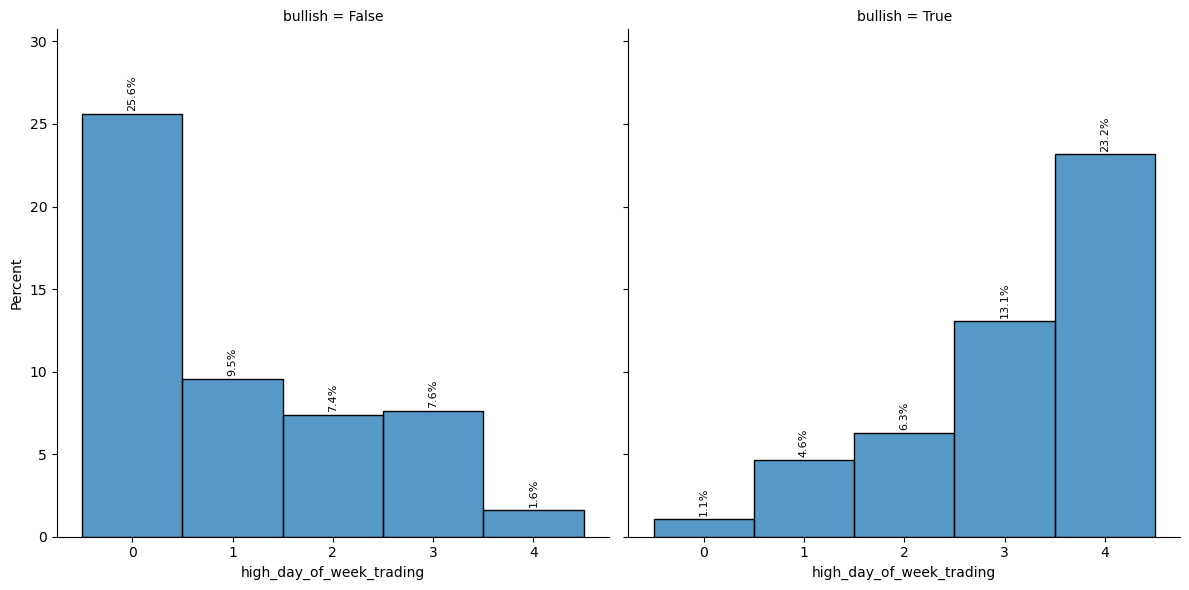

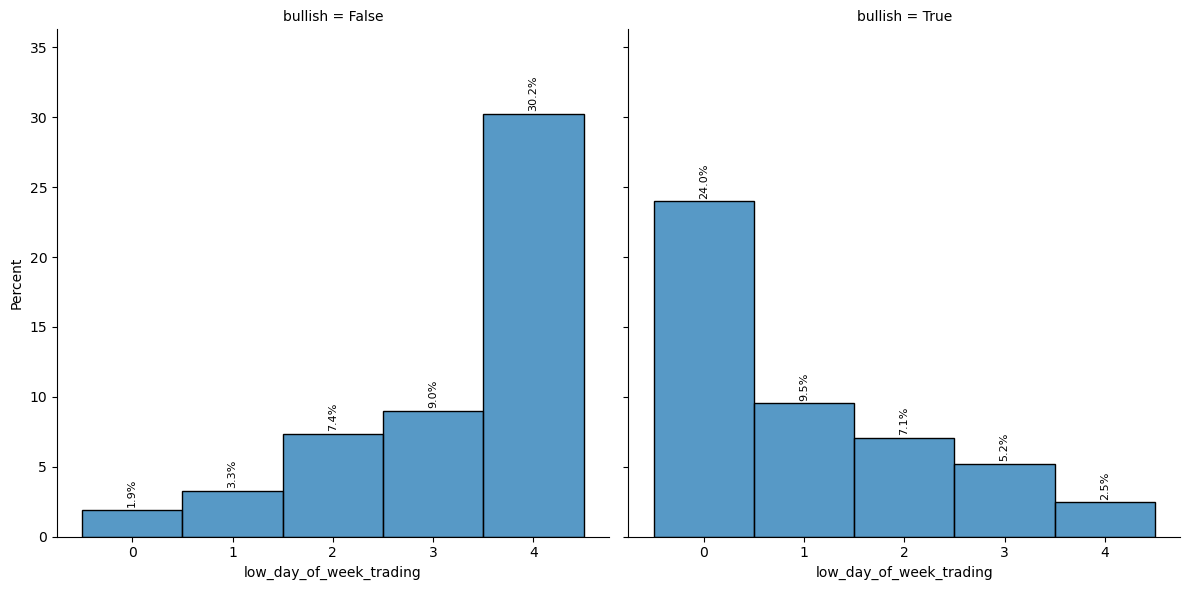

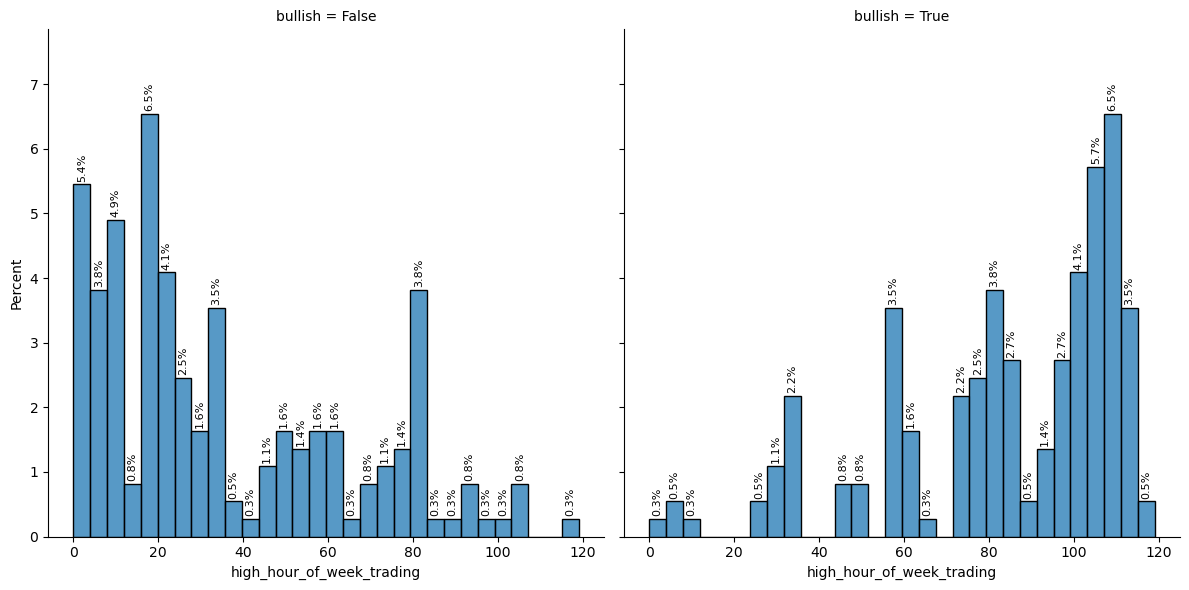

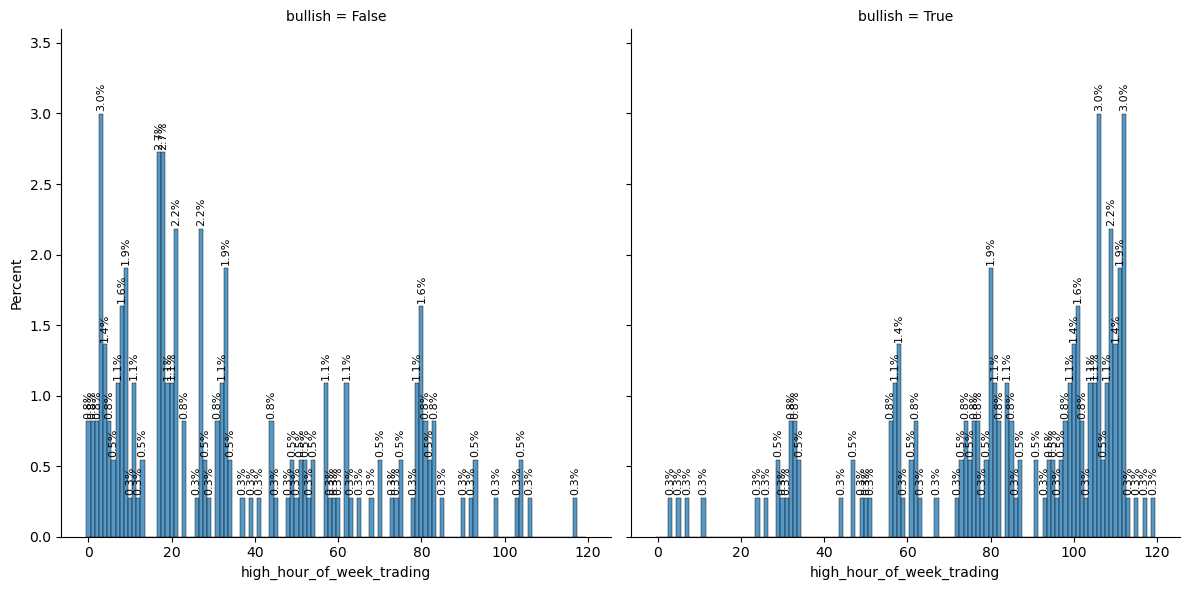

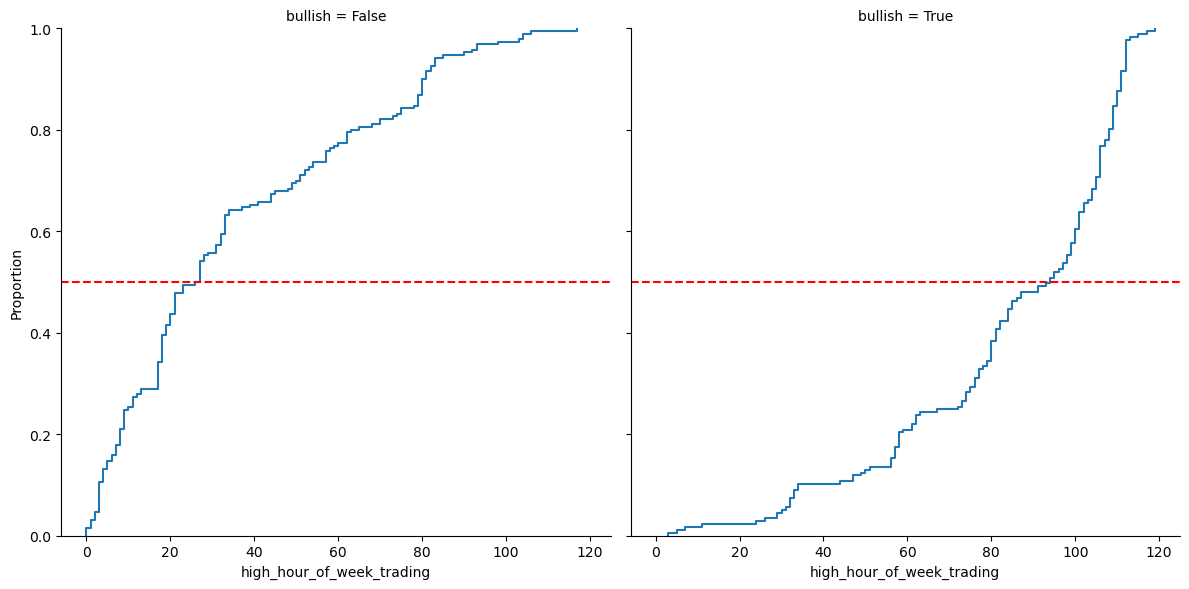

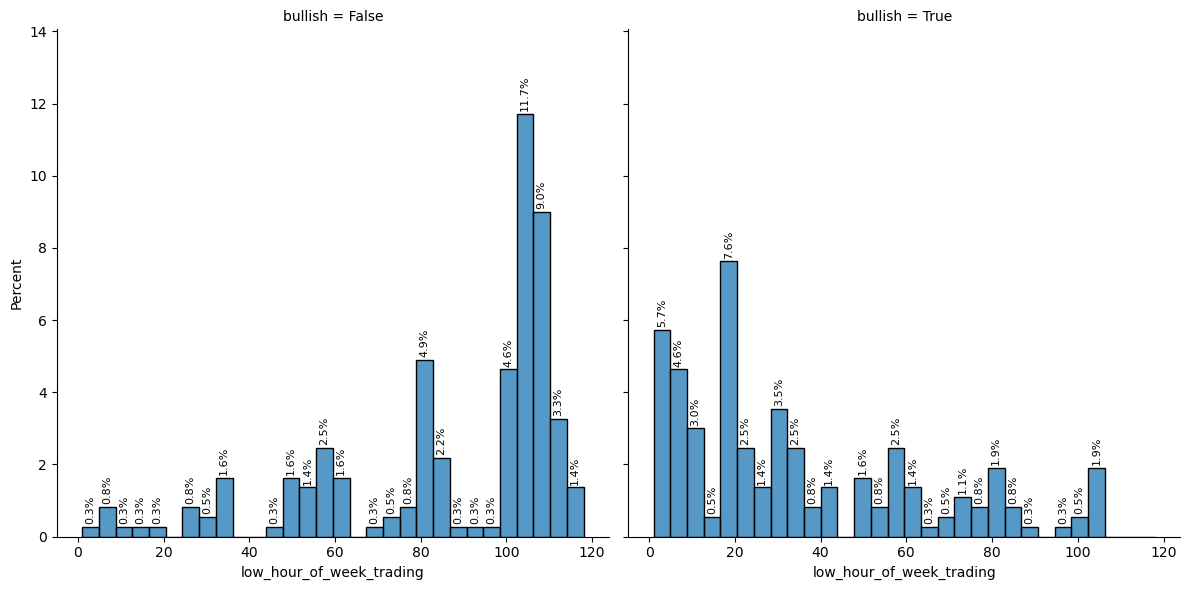

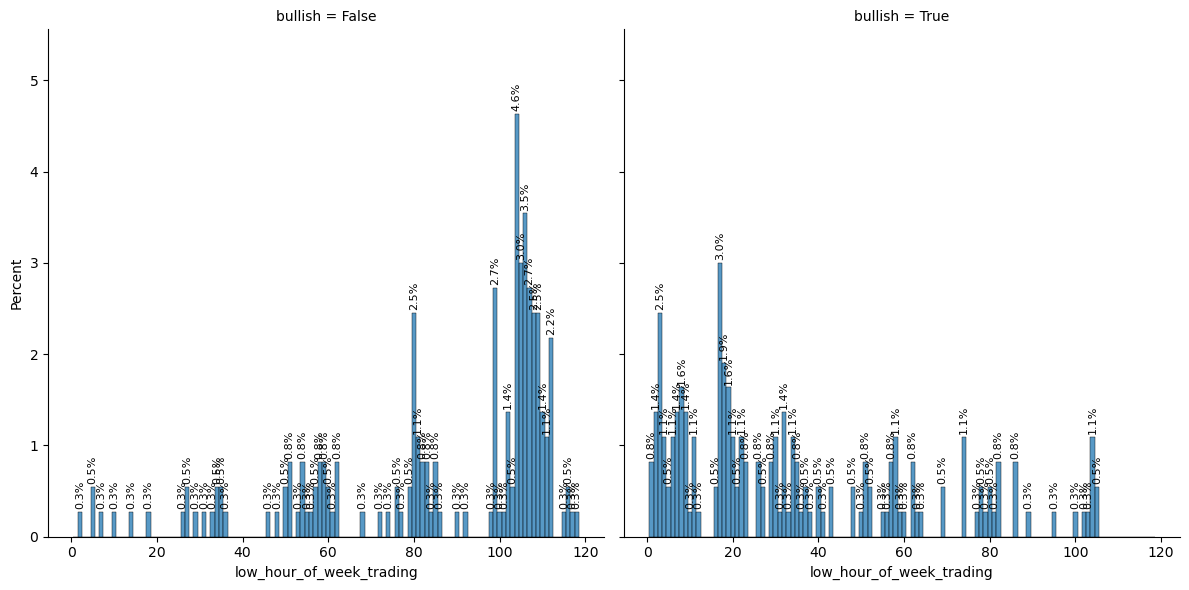

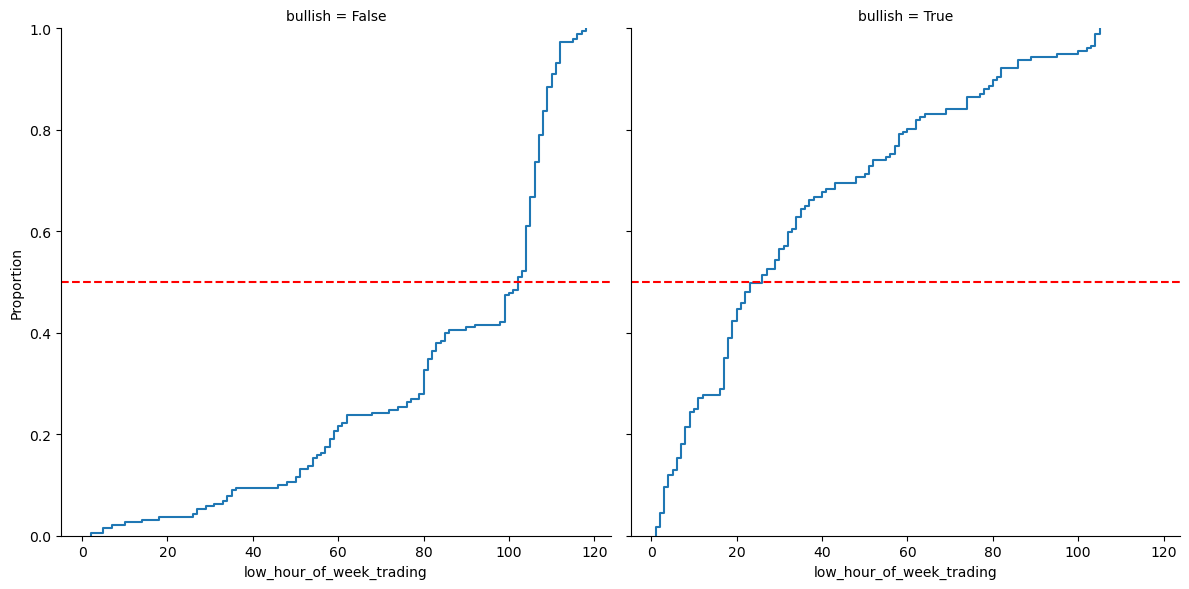

In [608]:
df_vis = df_weekly
upbars = df_vis.bullish

g = sns.displot(kind='hist', x=df_vis.high_day_of_week_trading, col=upbars, height=6, stat='percent', discrete=True)
add_lables(g)

g = sns.displot(kind='hist', x=df_vis.low_day_of_week_trading, col=upbars, height=6, stat='percent', discrete=True)
add_lables(g)

g = sns.displot(kind='hist', x=df_vis.high_hour_of_week_trading, col=upbars, height=6, stat='percent', bins=30)
add_lables(g)

g = sns.displot(kind='hist', x=df_vis.high_hour_of_week_trading, col=upbars, height=6, stat='percent', discrete=True)
add_lables(g)

g = sns.displot(kind='ecdf', x=df_vis.high_hour_of_week_trading, col=upbars, height=6, stat='proportion')
g.map(plt.axhline, y=0.5, ls='--', c='red')

g = sns.displot(kind='hist', x=df_vis.low_hour_of_week_trading, col=upbars, height=6, stat='percent', bins=30)
add_lables(g)

g = sns.displot(kind='hist', x=df_vis.low_hour_of_week_trading, col=upbars, height=6, stat='percent', discrete=True)
add_lables(g)

g = sns.displot(kind='ecdf', x=df_vis.low_hour_of_week_trading, col=upbars, height=6, stat='proportion')
g.map(plt.axhline, y=0.5, ls='--', c='red')       